# Agent behavior

One greedy episode of the **trained** agents vs the **same world** driven by **random** agents (same seed): every panel shows what the learned policies buy.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import networkx as nx
import pandas as pd


def _find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "training" / "config.py").exists():
            return candidate
    raise RuntimeError("project root not found (training/config.py)")


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from core.config import DELIVERY_AGENTS, N_DELIVERY_WINDOWS, FruitKey
from core.fruits import get_params
from env.training_env import ColdChainTrainingEnv
from training.config import COMPARE_SEED, env_config, load_agents

AGENTS = ["temperature", "routing", "spoilage", "inventory", *DELIVERY_AGENTS]
SEED = COMPARE_SEED
KIND_ORDER = ["farm", "hub", "dc", "retail"]
KIND_COLOR = {"farm": "tab:green", "hub": "tab:blue", "dc": "tab:orange", "retail": "tab:red"}

plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## Record one episode: trained vs random (same seed)

In [2]:
from training.agents import RandomAgent
from training.config import build_agents


def record_episode(env, agents, learners):
    obs, _ = env.reset()
    s0 = env._state
    meta = {
        "fruit": s0.shipment.fruit_type.value,
        "source": s0.shipment.current_node,
        "target": s0.shipment.target_node,
        "weather": s0.ambient_weather.value,
        "ambient_temp_c": s0.ambient_temp_c,
    }
    path = [s0.shipment.current_node]
    rows = []
    done = False
    while not done:
        actions = {a: agents[a].act(obs[a], explore=False) for a in agents}
        obs, rewards, terminated, truncated, _ = env.step(actions)
        s = env._state.shipment
        row = {
            "tick": env._state.tick,
            "desired": s.desired_temperature_c,
            "sensor": s.sensor_temperature_c,
            "spoilage_risk": s.spoilage_risk,
            "energy": env._state.energy_usage,
            "route_travel_time": env._state.route_travel_time,
            "route_emissions": env._state.route_emissions,
            "spoilage_prediction": env._state.spoilage_prediction,
            "inventory_level": env._state.inventory_level,
            "inventory_order": env._state.inventory_order,
            "unmet_demand": env._state.unmet_demand,
        }
        for i, v in enumerate(env._state.vehicles):
            row[f"slot_{i}"] = v.chosen_slot
            row[f"conflict_{i}"] = float(v.conflict)
        for a in learners:
            row[f"reward_{a}"] = rewards[a]
        rows.append(row)
        path.append(s.current_node)
        done = terminated["__all__"] or truncated["__all__"]
    return pd.DataFrame(rows), path, meta


env = ColdChainTrainingEnv(env_config(SEED, AGENTS))
agents = load_agents(env, AGENTS)
df, path, meta = record_episode(env, agents, AGENTS)
graph = env._state.graph
vehicles = env._state.vehicles
max_steps = env._state.max_steps

env_r = ColdChainTrainingEnv(env_config(SEED, AGENTS))
agents_r = build_agents(env_r, AGENTS)
for a in AGENTS:
    agents_r[a] = RandomAgent(env_r.action_space(a))
df_r, path_r, _ = record_episode(env_r, agents_r, AGENTS)

fruit = get_params(FruitKey(meta["fruit"]))
delivered = path[-1] == meta["target"]
delivered_r = path_r[-1] == meta["target"]

print(f"{meta['fruit']}: {meta['source']} -> {meta['target']} "
      f"({meta['weather']}, ambient {meta['ambient_temp_c']:.1f} C)")
print(f"trained: {len(df)} steps, delivered={delivered}  |  "
      f"random: {len(df_r)} steps, delivered={delivered_r}")
df.head()

banana: farm_1 -> retail_1 (sunny, ambient 27.9 C)
trained: 3 steps, delivered=True  |  random: 20 steps, delivered=False


,tick,desired,sensor,spoilage_risk,energy,route_travel_time,route_emissions,spoilage_prediction,inventory_level,inventory_order,...,conflict_1,slot_2,conflict_2,reward_temperature,reward_routing,reward_spoilage,reward_inventory,reward_delivery_0,reward_delivery_1,reward_delivery_2
0,1,12.863865,14.126949,0.070412,1.377337,1.0,12.534612,0.0,0.894320,0.0,...,0.0,3,0.0,-1.856094,-1.036980,-0.0,-0.743434,-2.529518,-1.951301,-2.423993
1,2,13.114159,14.309222,0.145873,1.359110,3.0,16.038459,0.0,0.787291,0.0,...,0.0,3,0.0,-2.294100,-1.640974,-0.0,-0.697428,-2.529518,-1.951301,-2.423993
2,3,12.374260,14.021296,0.218040,1.387903,6.0,33.062292,0.0,0.593736,0.0,...,0.0,3,0.0,-1.675784,97.580593,-0.0,-0.621669,-2.529518,-1.951301,-2.423993


## Temperature control

Trained agent must hold the sensor inside the fruit's ideal band; random setpoints let it drift and drive spoilage risk up.

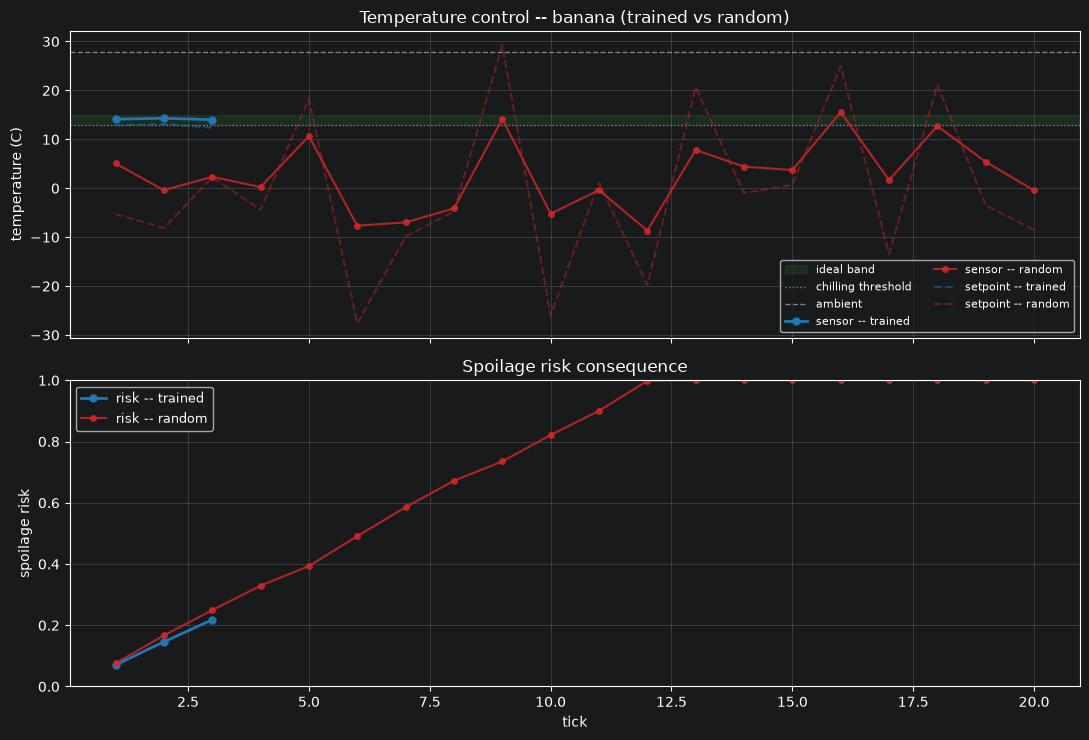

In [3]:
fig, (ax_t, ax_s) = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True)

ax_t.axhspan(fruit.optimal_temp_low_c, fruit.optimal_temp_high_c, color="tab:green", alpha=0.15, label="ideal band")
if fruit.chilling_injury_threshold_c is not None:
    ax_t.axhline(fruit.chilling_injury_threshold_c, color="tab:purple", ls=":", lw=1, label="chilling threshold")
ax_t.axhline(meta["ambient_temp_c"], color="tab:gray", ls="--", lw=1, label="ambient")
ax_t.plot(df["tick"], df["sensor"], marker="o", ms=5, color="tab:blue", lw=2, label="sensor -- trained")
ax_t.plot(df_r["tick"], df_r["sensor"], marker="o", ms=4, color="tab:red", lw=1.5, alpha=0.8, label="sensor -- random")
ax_t.plot(df["tick"], df["desired"], ms=3, ls="--", color="tab:blue", alpha=0.5, label="setpoint -- trained")
ax_t.plot(df_r["tick"], df_r["desired"], ms=3, ls="--", color="tab:red", alpha=0.4, label="setpoint -- random")
ax_t.set(ylabel="temperature (C)", title=f"Temperature control -- {meta['fruit']} (trained vs random)")
ax_t.legend(loc="best", fontsize=8, ncol=2)

ax_s.plot(df["tick"], df["spoilage_risk"], marker="o", ms=5, color="tab:blue", lw=2, label="risk -- trained")
ax_s.plot(df_r["tick"], df_r["spoilage_risk"], marker="o", ms=4, color="tab:red", lw=1.5, alpha=0.8, label="risk -- random")
ax_s.set(xlabel="tick", ylabel="spoilage risk", ylim=(0, 1), title="Spoilage risk consequence")
ax_s.legend(loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()

## Route

Trained DQN heads for the target along the cheap path; random walks/waits. Red = actual hops (numbered), green dashed = optimal path.

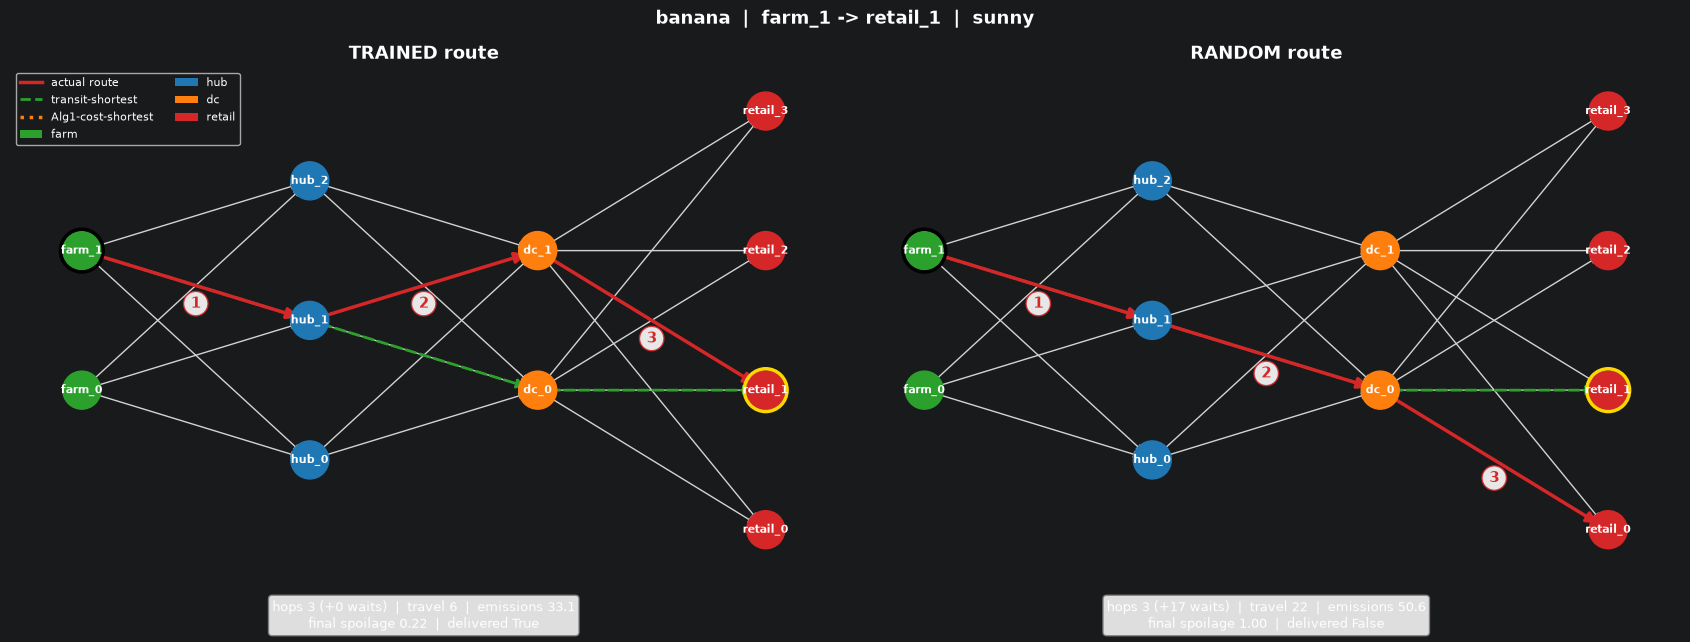

In [4]:
from env.training_env import ROUTE_EMISSIONS_WEIGHT, ROUTE_TIME_WEIGHT


def alg1_edge_cost(u, v, d):
    return ROUTE_TIME_WEIGHT * d["base_transit_time"] + ROUTE_EMISSIONS_WEIGHT * d["base_emissions"]


def layered_pos(graph):
    pos = {}
    for x, kind in enumerate(KIND_ORDER):
        nodes = [n for n, d in graph.nodes(data=True) if d["kind"] == kind]
        for i, n in enumerate(nodes):
            pos[n] = (float(x), i - (len(nodes) - 1) / 2)
    return pos


def draw_route(ax, graph, pos, ep_path, ep_df, title, delivered_flag):
    transport = [(u, v) for u, v, d in graph.edges(data=True) if not d["wait"]]
    nx.draw_networkx_edges(graph, pos, edgelist=transport, edge_color="lightgray", width=1, ax=ax)
    node_colors = [KIND_COLOR[graph.nodes[n]["kind"]] for n in graph.nodes]
    nx.draw_networkx_nodes(graph, pos, node_color=node_colors, node_size=750, ax=ax)
    nx.draw_networkx_labels(graph, pos, font_size=8, font_weight="bold", font_color="white", ax=ax)

    t_short = nx.shortest_path(graph, meta["source"], meta["target"], weight="base_transit_time")
    nx.draw_networkx_edges(graph, pos, edgelist=list(zip(t_short, t_short[1:])),
                           edge_color="tab:green", style="dashed", width=2, arrowsize=13, ax=ax)
    c_short = nx.shortest_path(graph, meta["source"], meta["target"], weight=alg1_edge_cost)
    if c_short != t_short:
        nx.draw_networkx_edges(graph, pos, edgelist=list(zip(c_short, c_short[1:])),
                               edge_color="tab:orange", style="dotted", width=2.5, arrowsize=13, ax=ax)

    hops = [(a, b) for a, b in zip(ep_path, ep_path[1:]) if a != b]
    nx.draw_networkx_edges(graph, pos, edgelist=hops, edge_color="tab:red", width=2.5, arrowsize=16, ax=ax)
    for order, (a, b) in enumerate(hops, start=1):
        x, y = (pos[a][0] + pos[b][0]) / 2, (pos[a][1] + pos[b][1]) / 2
        ax.text(x, y - 0.13, str(order), color="tab:red", fontsize=11, fontweight="bold",
                ha="center", va="center",
                bbox=dict(boxstyle="circle", fc="white", ec="tab:red", alpha=0.9))

    for node, ring in [(meta["source"], "black"), (meta["target"], "gold")]:
        nx.draw_networkx_nodes(graph, pos, nodelist=[node], node_color="none", edgecolors=ring,
                               linewidths=2.5, node_size=950, ax=ax)

    travel, emis = ep_df["route_travel_time"].iloc[-1], ep_df["route_emissions"].iloc[-1]
    waits = len(ep_path) - 1 - len(hops)
    caption = (f"hops {len(hops)} (+{waits} waits)  |  travel {travel:.0f}  |  emissions {emis:.1f}\n"
               f"final spoilage {ep_df['spoilage_risk'].iloc[-1]:.2f}  |  delivered {delivered_flag}")
    ax.text(0.5, -0.05, caption, transform=ax.transAxes, ha="center", va="top", fontsize=9,
            bbox=dict(boxstyle="round", fc="#f5f5f5", ec="gray", alpha=0.9))
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.axis("off")


pos = layered_pos(graph)
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(17, 6.5))
draw_route(ax_l, graph, pos, path, df, "TRAINED route", delivered)
draw_route(ax_r, graph, pos, path_r, df_r, "RANDOM route", delivered_r)
legend = [
    Line2D([0], [0], color="tab:red", lw=2.5, label="actual route"),
    Line2D([0], [0], color="tab:green", lw=2, ls="dashed", label="transit-shortest"),
    Line2D([0], [0], color="tab:orange", lw=2.5, ls="dotted", label="Alg1-cost-shortest"),
]
legend += [Patch(fc=KIND_COLOR[k], label=k) for k in KIND_ORDER]
ax_l.legend(handles=legend, loc="upper left", fontsize=8, ncol=2)
fig.suptitle(f"{meta['fruit']}  |  {meta['source']} -> {meta['target']}  |  {meta['weather']}",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## Why the trained path can differ from the shortest

The green baseline is shortest by **transit time only** -- but the agent optimizes the paper's Alg 1 cost: dynamic-Pareto weighted **time + emissions + spoilage risk** plus the delivery bonus. Those are different yardsticks, so the reward-optimal route need not be the transit-shortest one. Any residual gap to the true cost-optimal path (table below) is DQN convergence noise on near-tied branches, amplified by the known action-aliasing (`action idx % len(out_edges)`; masked DQN is the deferred fix).

In [5]:
def forced_route(nodes_seq):
    """Replay the same-seed world forcing this node sequence; return routing return."""
    fenv = ColdChainTrainingEnv(env_config(SEED, ["routing"]))
    fobs, _ = fenv.reset()
    fg = fenv._state.graph
    total, k, done = 0.0, 0, False
    while not done:
        cur = fenv._state.shipment.current_node
        targets = [v for _, v in fg.out_edges(cur)]
        if k + 1 < len(nodes_seq) and cur == nodes_seq[k]:
            idx = targets.index(nodes_seq[k + 1]); k += 1
        else:
            idx = targets.index(cur)
        fobs, fr, term, trunc, _ = fenv.step({"routing": idx})
        total += fr["routing"]
        done = term["__all__"] or trunc["__all__"]
    return total


def path_stats(name, p):
    tr = sum(graph.edges[u, v]["base_transit_time"] for u, v in zip(p, p[1:]))
    em = sum(graph.edges[u, v]["base_emissions"] for u, v in zip(p, p[1:]))
    return {"path": name, "route": " -> ".join(p), "transit": tr,
            "emissions": round(em, 1),
            "alg1_edge_cost": round(ROUTE_TIME_WEIGHT * tr + ROUTE_EMISSIONS_WEIGHT * em, 2),
            "routing_return": round(forced_route(p), 2)}


actual = [meta["source"]] + [b for a, b in zip(path, path[1:]) if a != b]
t_short = nx.shortest_path(graph, meta["source"], meta["target"], weight="base_transit_time")
c_short = nx.shortest_path(graph, meta["source"], meta["target"], weight=alg1_edge_cost)

rows = [path_stats("actual (agent)", actual), path_stats("transit-shortest", t_short)]
if c_short != t_short:
    rows.append(path_stats("Alg1-cost-shortest", c_short))
table = pd.DataFrame(rows).set_index("path")
display(table)

gap = table.loc["actual (agent)", "routing_return"] - table["routing_return"].max()
best = table["routing_return"].idxmax()
print(f"agent vs best ({best}): return gap {gap:+.2f} "
      f"({gap / abs(table['routing_return'].max()):+.1%} of return)")

,route,transit,emissions,alg1_edge_cost,routing_return
path,,,,,
actual (agent),farm_1 -> hub_1 -> dc_1 -> retail_1,6,33.1,9.31,94.87
transit-shortest,farm_1 -> hub_1 -> dc_0 -> retail_1,5,39.0,8.90,95.28


agent vs best (transit-shortest): return gap -0.41 (-0.4% of return)


## Spoilage prediction

Trained predictor tracks the Arrhenius risk; random prediction is noise around 0.5.

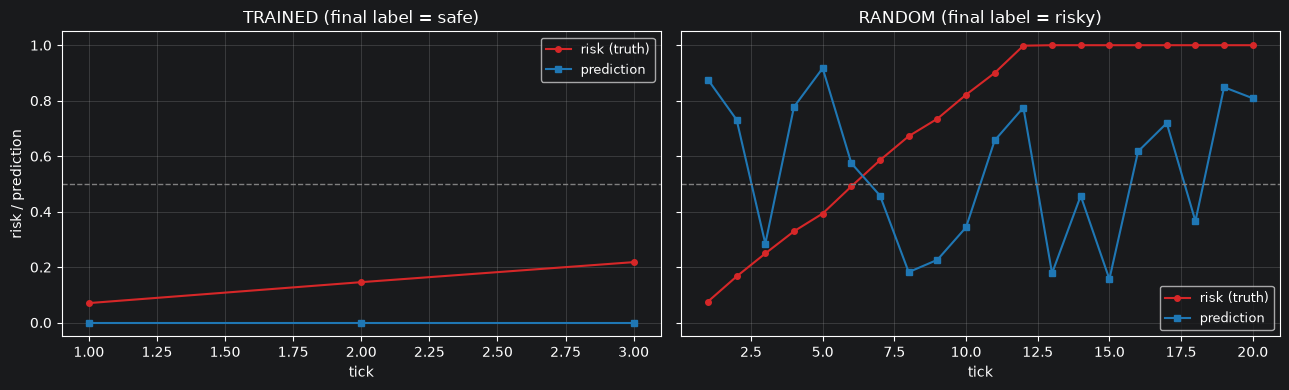

In [6]:
from core.spoilage import risk_to_label

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, d, tag in ((ax_l, df, "TRAINED"), (ax_r, df_r, "RANDOM")):
    ax.plot(d["tick"], d["spoilage_risk"], marker="o", ms=4, color="tab:red", label="risk (truth)")
    ax.plot(d["tick"], d["spoilage_prediction"], marker="s", ms=4, color="tab:blue", label="prediction")
    ax.axhline(0.5, ls="--", color="gray", lw=1)
    label = risk_to_label(d["spoilage_risk"].iloc[-1])
    ax.set(xlabel="tick", title=f"{tag} (final label = {'risky' if label else 'safe'})", ylim=(-0.05, 1.05))
    ax.legend(fontsize=9)
ax_l.set_ylabel("risk / prediction")
fig.tight_layout()
plt.show()

## Inventory control

Alg 4 cost punishes holding, orders, spoilage-weighted stock. Trained keeps level lean without piling unmet demand; random over/under-orders.

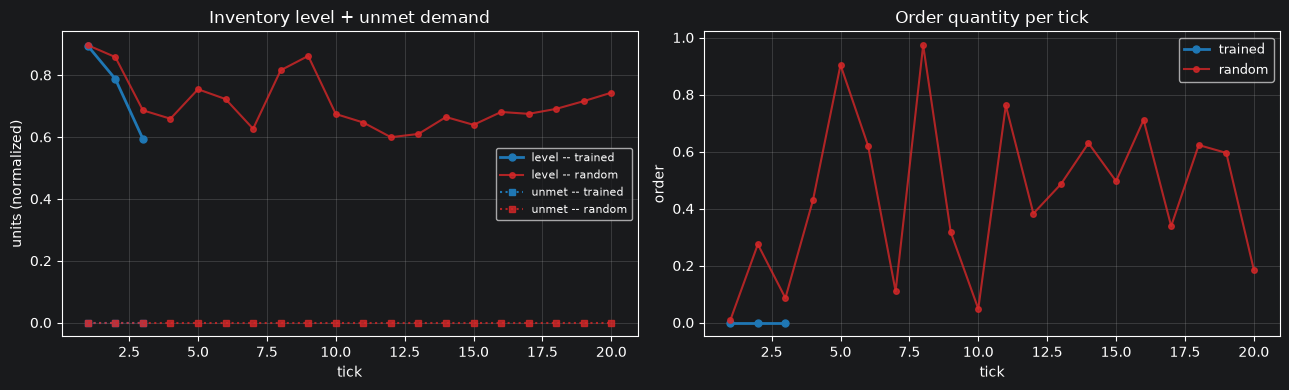

In [7]:
fig, (ax_l, ax_o) = plt.subplots(1, 2, figsize=(13, 4))
ax_l.plot(df["tick"], df["inventory_level"], marker="o", ms=5, color="tab:blue", lw=2, label="level -- trained")
ax_l.plot(df_r["tick"], df_r["inventory_level"], marker="o", ms=4, color="tab:red", lw=1.5, alpha=0.8, label="level -- random")
ax_l.plot(df["tick"], df["unmet_demand"], marker="s", ms=4, ls=":", color="tab:blue", label="unmet -- trained")
ax_l.plot(df_r["tick"], df_r["unmet_demand"], marker="s", ms=4, ls=":", color="tab:red", alpha=0.8, label="unmet -- random")
ax_l.set(xlabel="tick", ylabel="units (normalized)", title="Inventory level + unmet demand")
ax_l.legend(fontsize=8)

ax_o.plot(df["tick"], df["inventory_order"], marker="o", ms=5, color="tab:blue", lw=2, label="trained")
ax_o.plot(df_r["tick"], df_r["inventory_order"], marker="o", ms=4, color="tab:red", lw=1.5, alpha=0.8, label="random")
ax_o.set(xlabel="tick", ylabel="order", title="Order quantity per tick")
ax_o.legend(fontsize=9)
fig.tight_layout()
plt.show()

## Delivery scheduling

Vehicles must spread across slots (conflict -> rho) with the deadline covering route transit. Trained: distinct stable slots. Random: collisions (red x).

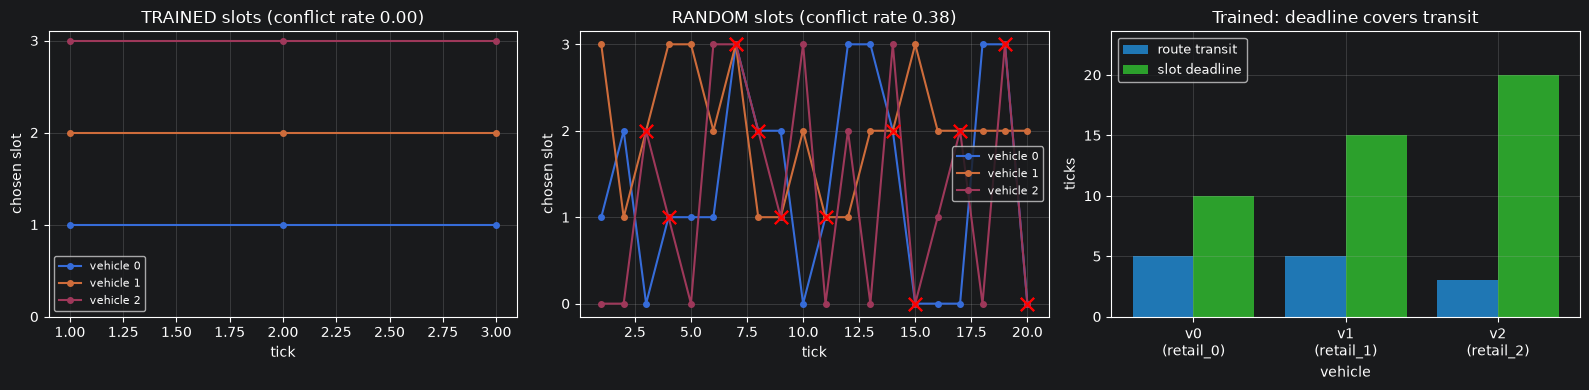

In [8]:
n_v = len(vehicles)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, d, tag in ((axes[0], df, "TRAINED"), (axes[1], df_r, "RANDOM")):
    for i in range(n_v):
        ax.plot(d["tick"], d[f"slot_{i}"], marker="o", ms=4, label=f"vehicle {i}")
        conf = d[d[f"conflict_{i}"] > 0]
        ax.scatter(conf["tick"], conf[f"slot_{i}"], marker="x", s=90, color="red", zorder=3)
    conf_rate = d[[f"conflict_{i}" for i in range(n_v)]].to_numpy().mean()
    ax.set(xlabel="tick", ylabel="chosen slot", yticks=range(N_DELIVERY_WINDOWS),
           title=f"{tag} slots (conflict rate {conf_rate:.2f})")
    ax.legend(fontsize=8)

slots_final = [df[f"slot_{i}"].iloc[-1] for i in range(n_v)]
deadlines = [(s + 1) / N_DELIVERY_WINDOWS * max_steps for s in slots_final]
transits = [v.route_transit for v in vehicles]
x = range(n_v)
axes[2].bar([i - 0.2 for i in x], transits, 0.4, label="route transit", color="tab:blue")
axes[2].bar([i + 0.2 for i in x], deadlines, 0.4, label="slot deadline", color="tab:green")
axes[2].set(xlabel="vehicle", ylabel="ticks", title="Trained: deadline covers transit",
            xticks=list(x), xticklabels=[f"v{i}\n({v.assigned_node})" for i, v in enumerate(vehicles)])
axes[2].legend(fontsize=9)
axes[2].margins(y=0.18)
fig.tight_layout()
plt.show()

## Rewards

Cumulative return per agent: trained (solid) vs random (dashed) on the same world.

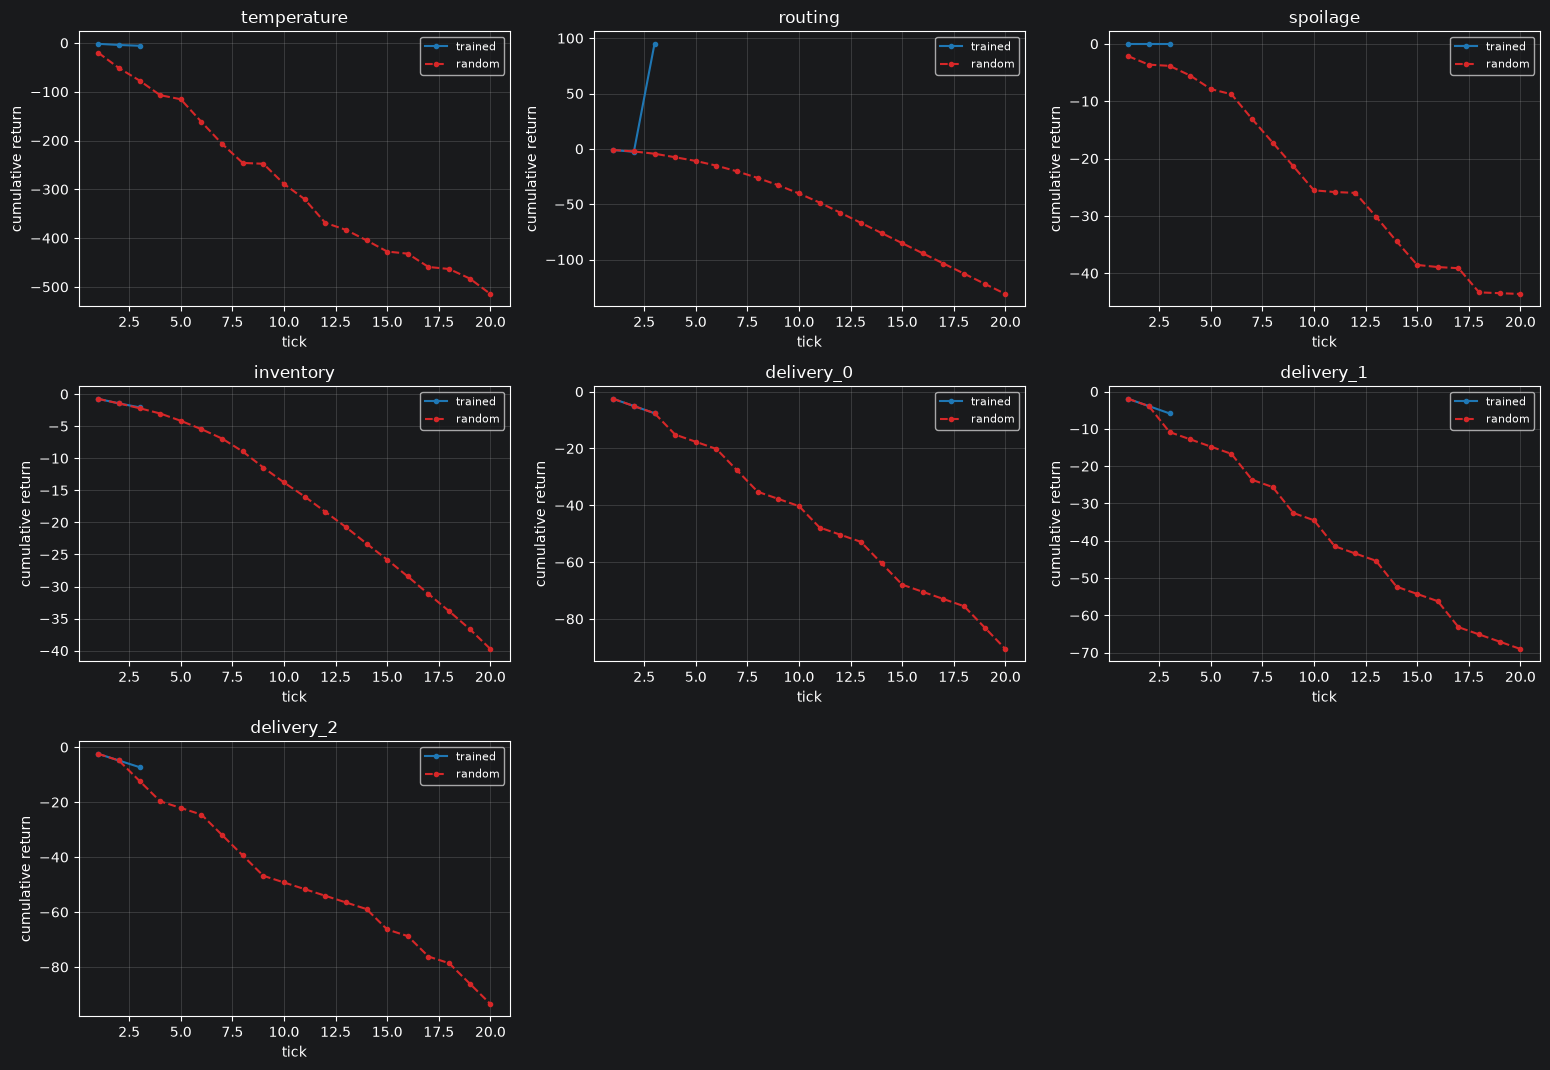

In [9]:
import math

cols = 3
rows = math.ceil(len(AGENTS) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(5.2 * cols, 3.6 * rows), squeeze=False)
for k, a in enumerate(AGENTS):
    ax = axes[k // cols][k % cols]
    col = f"reward_{a}"
    ax.plot(df["tick"], df[col].cumsum(), marker="o", ms=3, color="tab:blue", label="trained")
    ax.plot(df_r["tick"], df_r[col].cumsum(), marker="o", ms=3, ls="--", color="tab:red", label="random")
    ax.set(xlabel="tick", ylabel="cumulative return", title=a)
    ax.legend(fontsize=8)
for k in range(len(AGENTS), rows * cols):
    axes[k // cols][k % cols].axis("off")
fig.tight_layout()
plt.show()